<a href="https://colab.research.google.com/github/Alfredosernas/Machine-Learning/blob/main/hans_on3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##paso 1:Importar los paquetes de python necesarios.
se necesita la libreria de pandas para manipulacion de datos,Numpy para calculos matematicos y Matplotlib y seaborn para visualizacion.


In [1]:
import pandas as pd #se utiliza import para usar las librerias y as para referenciarla
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from pandas.core.common import random_state
from sklearn.linear_model import LinearRegression #se utiliza para operaciones de aprendizaje automaticos
import kagglehub


##paso 2:Cargar el conjunto de datos
Descargamos el conjunto de datos , subimos al notebook y leemos en el datagrame de pandas.

In [8]:
# Get dataset
df_sal = pd.read_csv('/content/Salary_Data.csv')
df_sal.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


##paso 3:Analisis de datos
Aora que tenemos nuestros datos listos, analicemos y comprendamos su tendencia.


In [9]:
#describe data
df_sal.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


##Visualizar datos en grafica
tambien se puede ver como se distribuyen los datos visualmente usando el grafico de distribucion de seaborn


/tmp/ipykernel_443/2671329880.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_sal['Salary'])


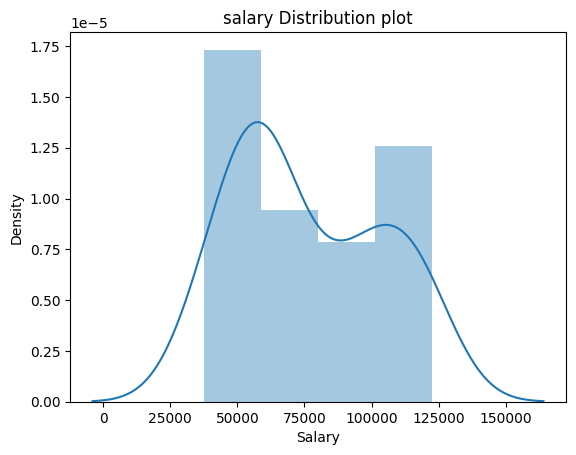

In [10]:
#data distribution
plt.title('salary Distribution plot') #titulo de la grafica
sns.distplot(df_sal['Salary']) #eje x o datos a graficar
plt.show()

##verificacion de datos
despues de ver los datos ordenados o ver mejor, verificamos la relacion que hay entre el salario y la experiencia.


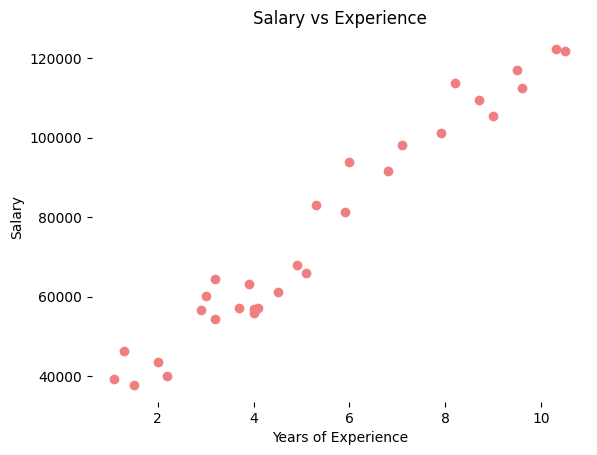

In [11]:
# relationship between salary and Experience
plt.scatter(df_sal['YearsExperience'],df_sal['Salary'],color='lightcoral')
plt.title('Salary vs Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.box(False)
plt.show()

##Dividir el conjunto de datos en variables dependientes e independientes.
La experienccia ($X$) es la variable independiente
El salario ($Y$) depende de la experiencia.



In [12]:
#splitting variables
X=df_sal.iloc[:,:1] # independent
y=df_sal.iloc[:,1:] # dependent


##paso 4:Divimos los datos en conuntos de entrenamiento y prueba.
Dividimos los datos en conjuntos de entrenamiento (80%) y prueba (20%) usando train_test_split

In [13]:
#splitting dataset into test/train
X_train,X_test,y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 0)

##paso5:Entrena el modelo de regresion
pasa los datods $x$_train e $y$_train al modelo regresor mediante regressor.fit pra encontrar el modelo con nuetros datos de entrenamiento.


In [14]:
#regressor model
regressor = LinearRegression()
regressor.fit(X_train, y_train)


LinearRegression()

##paso 6: predecir el resultado
Esta es la parte donde estamos listos para predecir cualquier valor de $y$ (salario) en la funcion de $x$(Experiencia) con el modelo regressor.predict.

In [15]:
#prediction result
y_pred_test = regressor.predict(X_test) # predicted value of y_test
y_pred_train = regressor.predict(X_train) # predicted value of y train

##paso 7: Graficar los resultados del entrenamiento y las pruebas.
Graficamos los datos del conjunto de entrenamiento frente a las predicciones.
primero graficamos el resultado de los conjuntos de entrenamiento($x$_train,$y$_train) y el valor predicho de $y_train$(regressor.predict($x$_train))


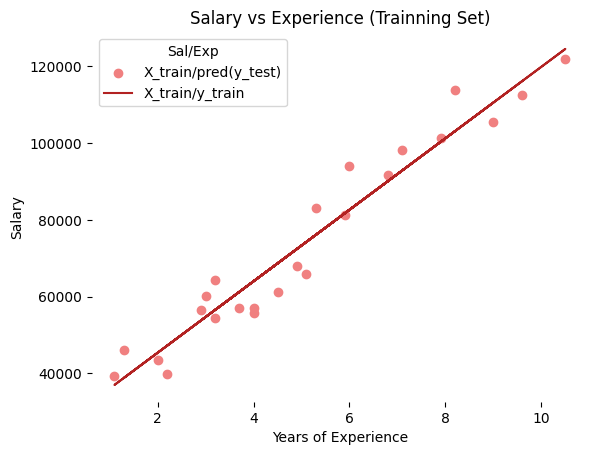

In [16]:

# prediction on training set
plt.scatter(X_train, y_train, color = 'lightcoral')
plt.plot(X_train, y_pred_train, color = 'firebrick')
plt.title('Salary vs Experience (Trainning Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend(['X_train/pred(y_test)','X_train/y_train'],title='Sal/Exp',loc='best',facecolor='white')
plt.box(False)
plt.show()

###Graficamos los datos del conjunto de pruebas frente a las predicciones
En segundo lugar,graficamos el resultado de los conjuntos de prueba($X$_test,$y$_test)con $X$_train y el valor predicho de $y$_train (regressor.predict($X$_train)

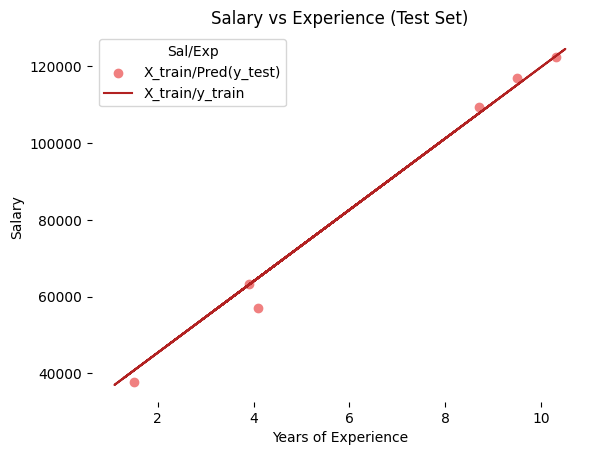

In [17]:

# Prediction on test set
plt.scatter(X_test, y_test, color = 'lightcoral')
plt.plot(X_train, y_pred_train, color = 'firebrick')
plt.title('Salary vs Experience (Test Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend(['X_train/Pred(y_test)', 'X_train/y_train'], title = 'Sal/Exp', loc='best', facecolor='white')
plt.box(False)
plt.show()

ecuación lineal y = mx + c , también podemos obtener c (ordenada al origen) y m (pendiente/coeficiente) del modelo regresor.

In [18]:


#regressor coefficients and intercept
print(f'Coefficient: {regressor.coef_}')
print(f'Intercept: {regressor.intercept_}')

Coefficient: [[9312.57512673]]
Intercept: [26780.09915063]
